# Language Detection — Exploratory Data Analysis

Multi-class language identification: predict which of 17 languages a short text snippet is written in (~10,300 samples). Because the task hinges on character patterns, cleaning keeps stemming OFF and stopword removal OFF.

**Text column:** `Text`  |  **Label column:** `Language`

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from collections import Counter
sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', 120)
%matplotlib inline

In [2]:
from utils import load_data
df = load_data()
print('Shape:', df.shape)
df.head()

Shape: (10337, 2)


,Text,Language
0,"Nature, in the broadest sense, is the natural, physical, material world or universe.",English
1,"""Nature"" can refer to the phenomena of the physical world, and also to life in general.",English
2,"The study of nature is a large, if not the only, part of science.",English
3,"Although humans are part of nature, human activity is often understood as a separate category from other natural phe...",English
4,"[1] The word nature is borrowed from the Old French nature and is derived from the Latin word natura, or ""essential ...",English


## 2. Dataset Overview

In [3]:
print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nDtypes:')
print(df.dtypes)

Shape: (10337, 2)

Columns: ['Text', 'Language']

Dtypes:
Text        object
Language    object
dtype: object


In [4]:
print('Duplicate rows:', df.duplicated().sum())
print('Missing per column:'); print(df.isnull().sum())

Duplicate rows: 66
Missing per column:
Text        0
Language    0
dtype: int64


## 3. Target / Label Distribution

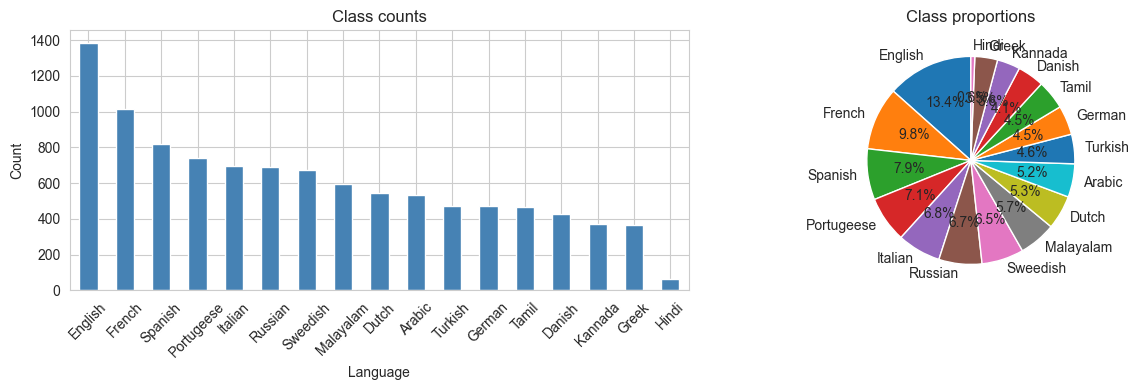

Class balance (%):
Language
English       13.40
French         9.81
Spanish        7.92
Portugeese     7.15
Italian        6.75
Russian        6.69
Sweedish       6.54
Malayalam      5.75
Dutch          5.28
Arabic         5.19
Turkish        4.59
German         4.55
Tamil          4.54
Danish         4.14
Kannada        3.57
Greek          3.53
Hindi          0.61
Name: count, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = df['Language'].value_counts()
counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Class counts'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class proportions')
plt.tight_layout(); plt.show()
print('Class balance (%):')
print((counts / counts.sum() * 100).round(2))

## 4. Text Length Analysis

In [6]:
df['char_count'] = df['Text'].astype(str).str.len()
df['word_count'] = df['Text'].astype(str).str.split().str.len()
df[['char_count', 'word_count']].describe().round(1)

,char_count,word_count
count,10337.0,10337.0
mean,124.1,19.6
std,253.7,48.4
min,1.0,1.0
25%,43.0,7.0
50%,100.0,15.0
75%,166.0,25.0
max,19088.0,3735.0


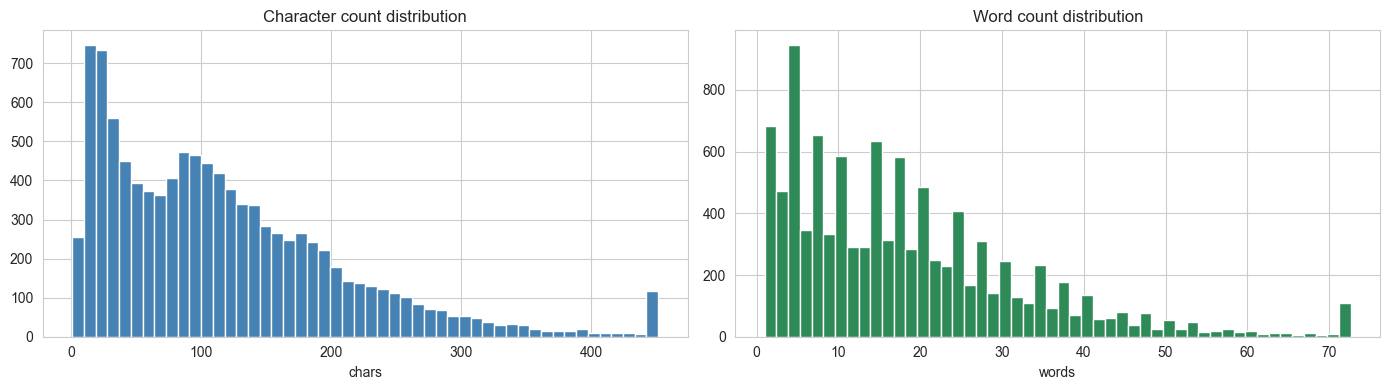

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['char_count'].clip(upper=df['char_count'].quantile(0.99)).hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Character count distribution'); axes[0].set_xlabel('chars')
df['word_count'].clip(upper=df['word_count'].quantile(0.99)).hist(bins=50, ax=axes[1], color='seagreen')
axes[1].set_title('Word count distribution'); axes[1].set_xlabel('words')
plt.tight_layout(); plt.show()

## 5. Text Length by Class

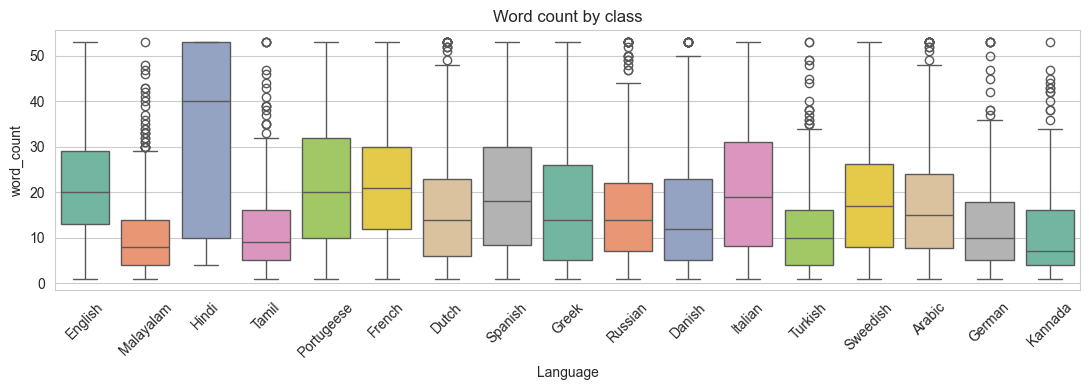

,count,mean,std,min,25%,50%,75%,max
Language,,,,,,,,
Arabic,536.0,17.9,14.0,1.0,7.8,15.0,24.0,95.0
Danish,428.0,16.8,16.2,1.0,5.0,12.0,23.0,142.0
Dutch,546.0,17.1,14.8,1.0,6.0,14.0,23.0,146.0
English,1385.0,21.9,13.5,1.0,13.0,20.0,29.0,142.0
French,1014.0,22.9,16.3,1.0,12.0,21.0,30.0,156.0
German,470.0,12.6,10.3,1.0,5.0,10.0,17.8,76.0
Greek,365.0,17.7,16.2,1.0,5.0,14.0,26.0,127.0
Hindi,63.0,235.1,552.8,4.0,10.0,40.0,250.5,3735.0
Italian,698.0,22.1,17.7,1.0,8.2,19.0,31.0,144.0


In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
clip_val = df['word_count'].quantile(0.97)
sns.boxplot(x='Language', y=df['word_count'].clip(upper=clip_val), data=df, ax=ax, palette='Set2')
ax.set_title('Word count by class'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
df.groupby('Language')['word_count'].describe().round(1)

## 6. Most Frequent Words (raw, pre-cleaning)

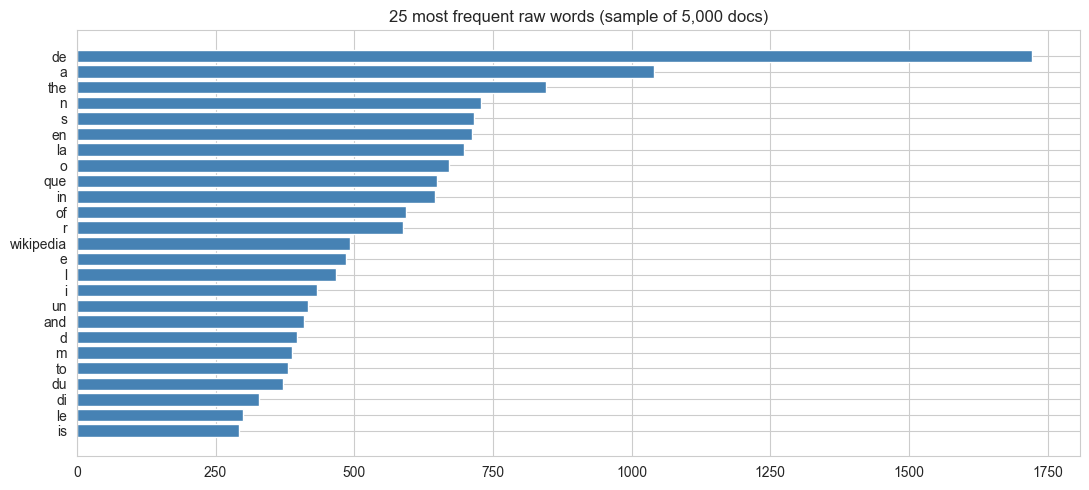

In [9]:
import re
def quick_tokens(text):
    return re.findall(r'[a-zA-Z]+', str(text).lower())
all_words = Counter()
for t in df['Text'].astype(str).sample(min(len(df), 5000), random_state=42):
    all_words.update(quick_tokens(t))
common = all_words.most_common(25)
plt.figure(figsize=(11, 5))
plt.barh([w for w, _ in common][::-1], [c for _, c in common][::-1], color='steelblue')
plt.title('25 most frequent raw words (sample of 5,000 docs)')
plt.tight_layout(); plt.show()

## 7. Word Clouds per Class

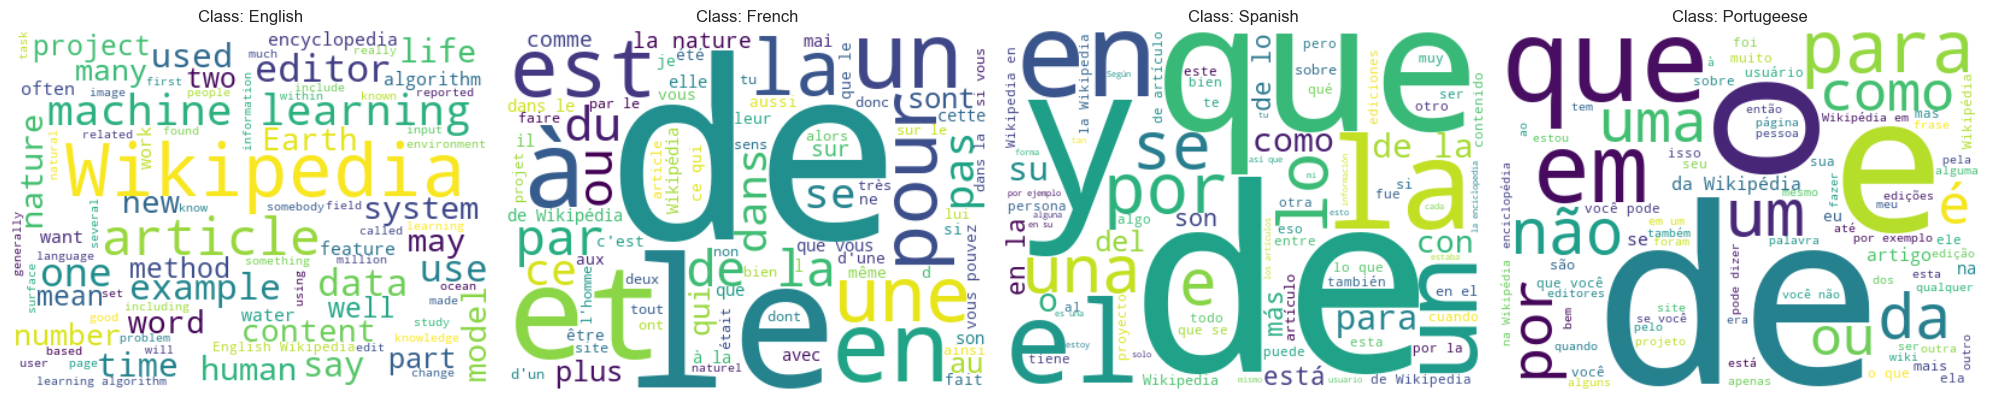

In [10]:
from wordcloud import WordCloud
classes = df['Language'].value_counts().index.tolist()[:4]
fig, axes = plt.subplots(1, len(classes), figsize=(5*len(classes), 4))
if len(classes) == 1: axes = [axes]
for ax, cls in zip(axes, classes):
    text = ' '.join(df[df['Language'] == cls]['Text'].astype(str).sample(min(2000, (df['Language']==cls).sum()), random_state=42))
    wc = WordCloud(width=400, height=300, background_color='white', max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off'); ax.set_title(f'Class: {cls}')
plt.tight_layout(); plt.show()

## 9. Summary of Key Findings

In [11]:
summary = pd.DataFrame({
    'Metric': ['Total documents', 'Number of classes', 'Most common class',
               'Least common class', 'Mean word count', 'Median word count',
               'Max word count', 'Duplicate rows'],
    'Value': [
        len(df), df['Language'].nunique(),
        str(df['Language'].value_counts().idxmax()),
        str(df['Language'].value_counts().idxmin()),
        round(df['word_count'].mean(), 1),
        int(df['word_count'].median()),
        int(df['word_count'].max()),
        int(df.duplicated().sum()),
    ],
})
summary

,Metric,Value
0,Total documents,10337
1,Number of classes,17
2,Most common class,English
3,Least common class,Hindi
4,Mean word count,19.6
5,Median word count,15
6,Max word count,3735
7,Duplicate rows,66
